In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA OVERVIEW

# Credit Card Customer Dataset - Data Dictionary

> Dataset gốc: 8950 khách hàng, 18 cột, phản ánh hành vi sử dụng thẻ tín dụng trong 6 tháng gần nhất.

---

## Thông tin khách hàng

| Cột | Kiểu | Mô tả |
|-----|------|-------|
| **CUST_ID** | string | Mã định danh duy nhất (vd: C10001). **Không dùng trong phân tích**, chỉ dùng để nhận diện khách hàng. |

---

## Nhóm 1 — Số dư & Tần suất cập nhật

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **BALANCE** | float | Số dư nợ còn lại trong tài khoản để mua hàng (số tiền chưa trả). Càng cao = nợ càng nhiều. | Số dư: $1,500 → khách đang nợ ngân hàng $1,500 chưa trả |
| **BALANCE_FREQUENCY** | float (0–1) | Tần suất cập nhật số dư. 1 = cập nhật mỗi kỳ, 0 = không cập nhật. | 0.9 → khách thanh toán gần như mỗi tháng; 0.2 → hiếm khi thanh toán |

---

## Nhóm 2 — Hành vi mua hàng

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **PURCHASES** | float | Tổng **số tiền** đã mua (bao gồm cả trả góp và đứt). | Tổng mua: $5,000/tháng → Purchase activity cao |
| **ONEOFF_PURCHASES** | float | **Số tiền** mua lớn nhất trong **một lần** mua đứt (không trả góp). | Mua TV $2,000 đứt một lần → ONEOFF = $2,000 |
| **INSTALLMENTS_PURCHASES** | float | **Số tiền** mua theo hình thức **trả góp**. | Mua máy $1,200 chia 6 tháng → INSTALLMENTS = $1,200 |
| **PURCHASES_FREQUENCY** | float (0–1) | Tần suất mua hàng **tổng thể** (mọi hình thức). 1 = luôn luôn có giao dịch. | 0.9 → mua gần như mỗi tháng |
| **ONEOFF_PURCHASES_FREQUENCY** | float (0–1) | Tần suất mua **đứt** (không trả góp). 1 = chỉ mua đứt. | 1.0 → luôn mua đứt; 0.2 → hiếm khi mua đứt (thường trả góp) |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | float (0–1) | Tần suất mua **trả góp**. 1 = luôn trả góp. | 0.8 → thường xuyên mua trả góp |
| **PURCHASES_TRX** | int | **Số lượng giao dịch mua** (đếm giao dịch, không phải số tiền). | 45 giao dịch → khách rất active |

> **Quan hệ quan trọng:**
> - `PURCHASES` = `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES`
> - `PURCHASES_FREQUENCY` ≥ `ONEOFF_PURCHASES_FREQUENCY` + `PURCHASES_INSTALLMENTS_FREQUENCY`

---

## Nhóm 3 — Rút tiền mặt (Cash Advance)

> Cash Advance = rút tiền mặt từ thẻ tín dụng. Phí cao, lãi suất cao hơn mua hàng. Thường là dấu hiệu cần tiền gấp.

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **CASH_ADVANCE** | float | Tổng **số tiền** đã rút mặt từ thẻ. | Rút $3,000 → khách có thể đang gặp khó khăn tài chính |
| **CASH_ADVANCE_FREQUENCY** | float (0–1) | Tần suất rút tiền mặt. 1 = rút mỗi tháng. | 0.5 → rút tiền cách tháng |
| **CASH_ADVANCE_TRX** | int | **Số lượng giao dịch** rút tiền mặt. | 8 lần rút → thường xuyên rút tiền |

---

## Nhóm 4 — Thanh toán & Hạn mức

| Cột | Kiểu | Mô tả | Ví dụ thực tế |
|-----|------|-------|---------------|
| **CREDIT_LIMIT** | float | **Hạn mức** thẻ tín dụng tối đa. | Hạn mức: $10,000 → ngân hàng tin tưởng khách |
| **PAYMENTS** | float | Tổng **số tiền** đã thanh toán (trả nợ). | Trả $2,000/tháng → khách có trách nhiệm tài chính |
| **MINIMUM_PAYMENTS** | float | Số tiền **than toán tối thiểu** bắt buộc mỗi tháng (thường ~5% số dư). | Minimum payment: $50/tháng |
| **PRC_FULL_PAYMENT** | float (0–1) | Tỷ lệ **thanh toán đủ** (trả hết số dư). 1 = luôn trả hết nợ. | 0.1 → chỉ trả đủ 10% số dư; 0.9 → thường xuyên trả hết |
| **TENURE** | int | **Thời hạn** sử dụng thẻ (tháng). Hầu hết = 12 (mới nhất). | TENURE = 12 → khách dùng thẻ từ đầu (thường là khách mới) |



In [191]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [192]:
df = pd.read_csv('/content/drive/MyDrive/ML/CC GENERAL.csv')

In [193]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [194]:
df.shape

(8950, 18)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [196]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Dataset Summary

### Thông tin chung
- **8,950 khách hàng**, 18 cột, hành vi trong 6 tháng
- Missing values: MINIMUM_PAYMENTS (313), CREDIT_LIMIT (1)

---

### Insight 1: Đa số khách nhỏ, ít hoạt động
| Metric | Mean | Median | Bottom 25% |
|--------|------|--------|-----------|
| PURCHASES | $1,003 | $361 | < $39 |
| PURCHASES_TRX | 14.7 lần | 7 lần | ≤ 1 lần |

- `PURCHASES_TRX 25% = 1` → **25% khách chỉ mua 1 lần** trong 6 tháng
- `TENURE TB = 11.5/12` → Hầu hết khách **dùng thẻ từ đầu**

---

### Insight 2: Phân hóa mạnh — thiểu số kéo trung bình lên
| | Mean | Median | Max |
|---|---|---|---|
| BALANCE | $1,564 | $873 | $19,043 |
| CREDIT_LIMIT | $4,494 | $3,000 | $30,000 |
| ONEOFF_PURCHASES | $592 | $38 | $40,761 |

- **Mean >> Median** ở mọi feature → Phân phối **lệch phải** (right-skewed)
- Max gấp 10-60 lần mean → Thiểu số "heavy user" kéo giá trị trung bình

---

### Insight 3: Rủi ro tài chính — rút tiền mặt & không trả nợ
| | Mean | Median |
|---|---|---|
| CASH_ADVANCE | $979 | **$0** |
| PRC_FULL_PAYMENT | 15.4% | **0** |

- **Median CASH_ADVANCE = 0** → **>50% khách không bao giờ rút tiền mặt**, nhưng nhóm nhỏ rút rất nhiều (max = $47,137)
- **Median PRC_FULL_PAYMENT = 0** → **>50% khách KHÔNG trả hết nợ**

---

### Insight 4: Trả góp phổ biến hơn mua đứt
| Frequency | Mean |
|-----------|------|
| INSTALLMENTS_FREQUENCY | **0.36** |
| ONEOFF_PURCHASES_FREQUENCY | **0.20** |
| PURCHASES_FREQUENCY | **0.49** |

- Khách mua ít hơn nửa thời gian, và **ưa trả góp hơn mua đứt**
- Nhưng ONEOFF_PURCHASES > INSTALLMENT_PURCHASES về tổng tiền ($592 vs $411) → Khi mua đứt, mua với số tiền lớn hơn

---

### Clustering
Các feature có phân phối (tách nhóm tốt):

1. **BALANCE** — Đại diện cho số dư nợ — phản ánh rủi ro tài chính
2. **PURCHASES** — 	Đại diện cho hành vi mua hàng
3. **CREDIT_LIMIT** — Đại diện cho hạn mức/thu nhập
4. **PURCHASES_FREQUENCY** — Đại diện cho khả năng thanh toán

DATA CLEANING

In [197]:
df.duplicated().sum()

np.int64(0)

In [198]:
set(df['TENURE'])

{6, 7, 8, 9, 10, 11, 12}

In [199]:
df = df.drop_duplicates()

## 2. Xử lý Duplicate (hàng trùng lặp)

Kiểm tra và loại bỏ các hàng trùng lặp hoàn toàn trong dataset.

**Tại sao cần loại bỏ?**
- Hàng trùng lặp làm **kéo lệch kết quả** clustering/classification
- Trùng lặp = khách hàng xuất hiện 2 lần → bị đếm 2 lần → phân phối méo

In [200]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


## 3. Xử lý Missing Values

### Nguyên nhân có giá trị thiếu

| Cột | Số missing | Nguyên nhân có thể |
|------|-----------|-------------------|
| **MINIMUM_PAYMENTS** | 313 | Khách **không có dư nợ** → không cần trả minimum. Khi BALANCE = 0, ngân hàng không tính minimum payment. |
| **CREDIT_LIMIT** | 1 | Khách **không có thẻ tín dụng** active hoặc là khách hàng mới chưa được gán hạn mức. |

### Cách xử lý
- **`fillna(df.mean())`** → Thay missing bằng **giá trị trung bình** của cột đó
- **Không xóa hàng** vì 313/8950 = ~3.5% missing → ảnh hưởng nhỏ, không đáng kể

In [201]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [202]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [203]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [204]:
df.drop("CUST_ID", axis=1, inplace=True)

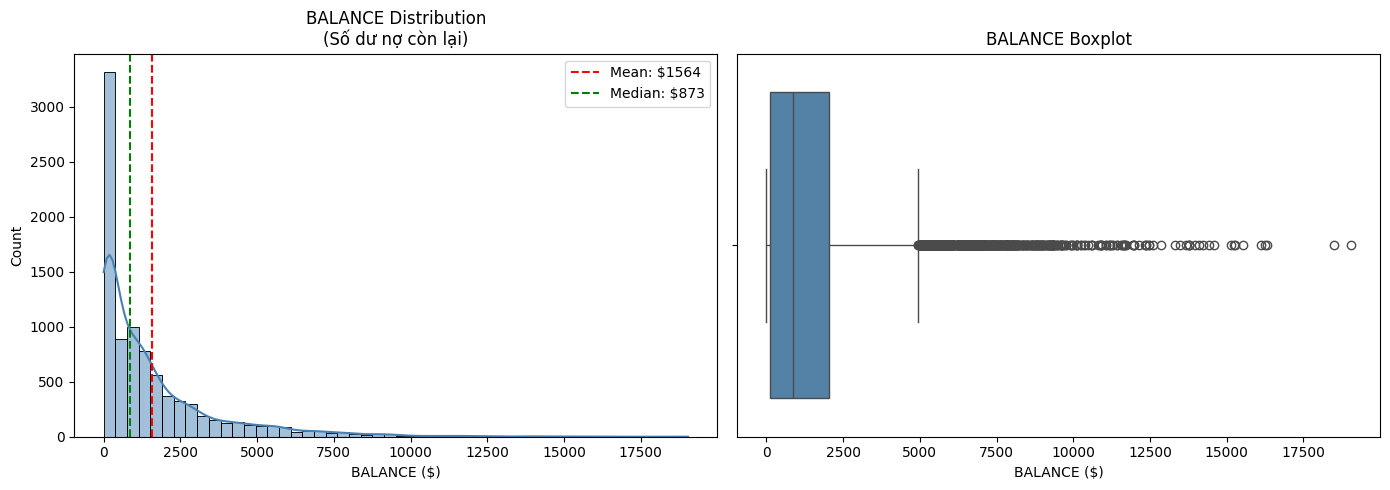

In [205]:
# =============================================
# Nhóm 1: Số dư (BALANCE)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['BALANCE'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BALANCE Distribution\n(Số dư nợ còn lại)', fontsize=12)
axes[0].set_xlabel('BALANCE ($)')
axes[0].axvline(df['BALANCE'].mean(), color='red', linestyle='--', label=f'Mean: ${df["BALANCE"].mean():.0f}')
axes[0].axvline(df['BALANCE'].median(), color='green', linestyle='--', label=f'Median: ${df["BALANCE"].median():.0f}')
axes[0].legend()

# Boxplot để thấy outliers
sns.boxplot(x=df['BALANCE'], ax=axes[1], color='steelblue')
axes[1].set_title('BALANCE Boxplot', fontsize=12)
axes[1].set_xlabel('BALANCE ($)')

plt.tight_layout()
plt.show()



### Nhóm 1 — Kết luận: Số dư (BALANCE)

| | Giá trị |
|---|---|
| Mean | $1,564 |
| Median | $873 |
| Max | $19,043 |
| Phân phối | **Lệch phải** (Mean >> Median) |

> → **Mean gấp ~2 lần Median** → Phân phối bị kéo bởi thiểu số khách có số dư rất cao
> → **Boxplot**: Rất nhiều outliers phía trên → Cần xử lý outliers trước khi clustering

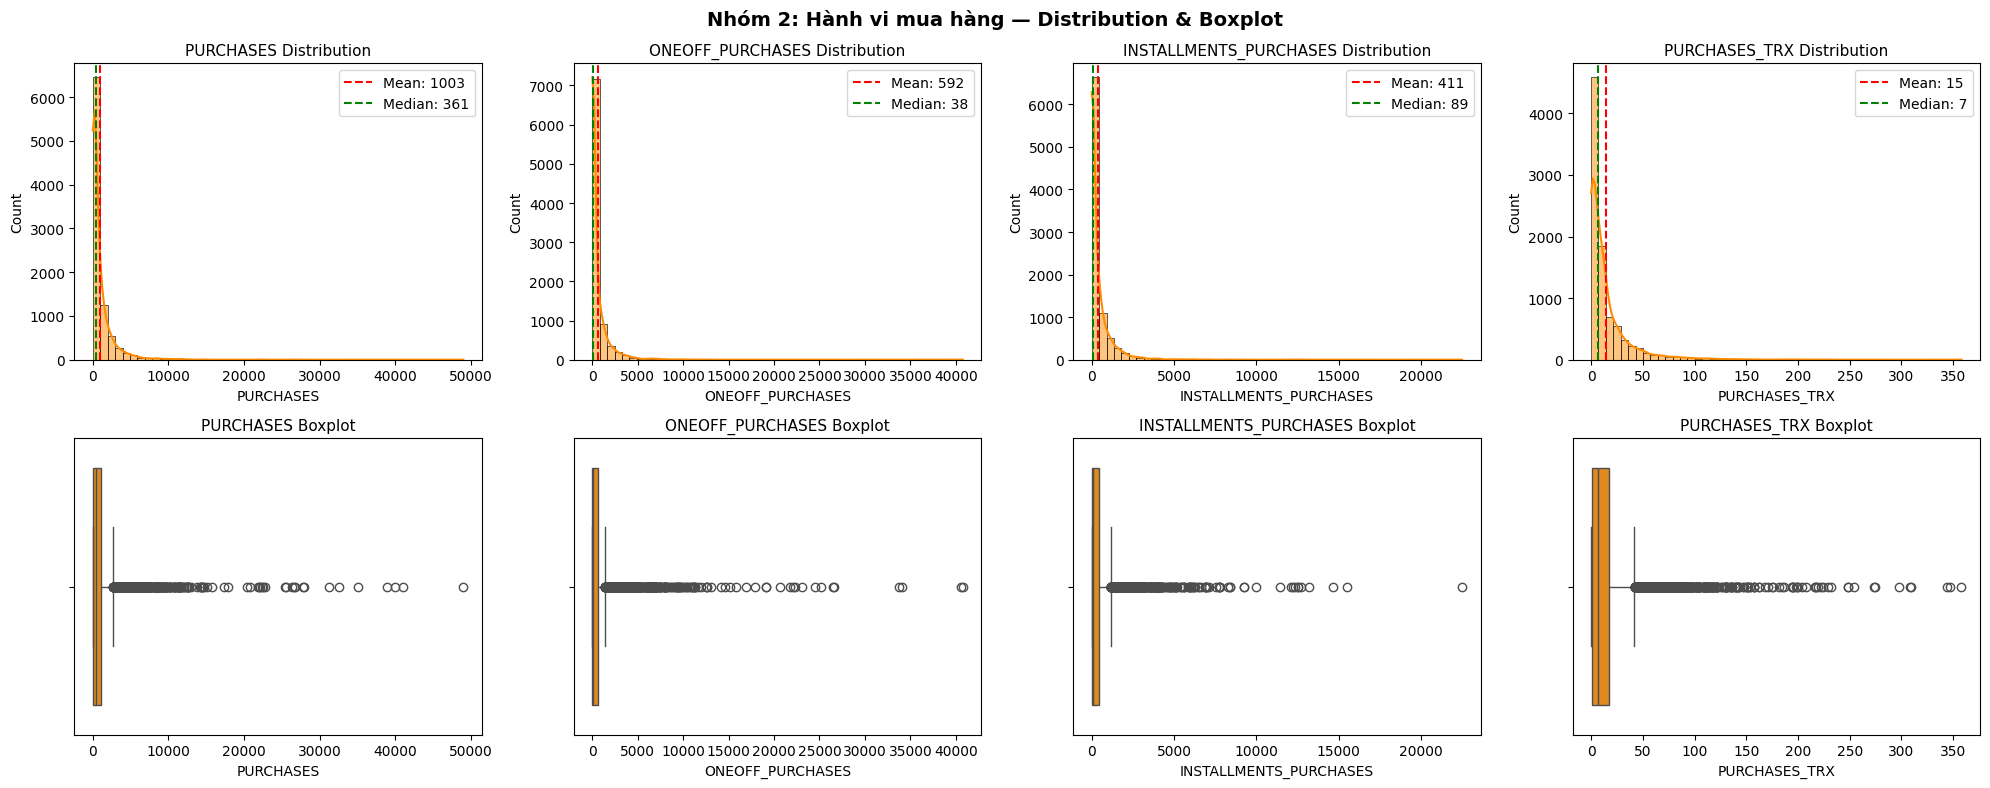

In [206]:
# =============================================
# Nhóm 2: Hành vi mua hàng (PURCHASES)
# =============================================
purchase_cols = ['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PURCHASES_TRX']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(purchase_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='darkorange')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='darkorange')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 2: Hành vi mua hàng — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Nhóm 2 — Kết luận: Hành vi mua hàng

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **PURCHASES** | $1,003 | $361 | Lệch phải nặng, đa số khách mua ít (<$500) |
| **ONEOFF_PURCHASES** | $592 | $38 | >50% khách không mua đứt |
| **INSTALLMENTS_PURCHASES** | $411 | $89 | Trả góp phổ biến hơn mua đứt (về tần suất) |
| **PURCHASES_TRX** | 14.7 | 7 | 25% khách chỉ mua 1 lần/6 tháng |

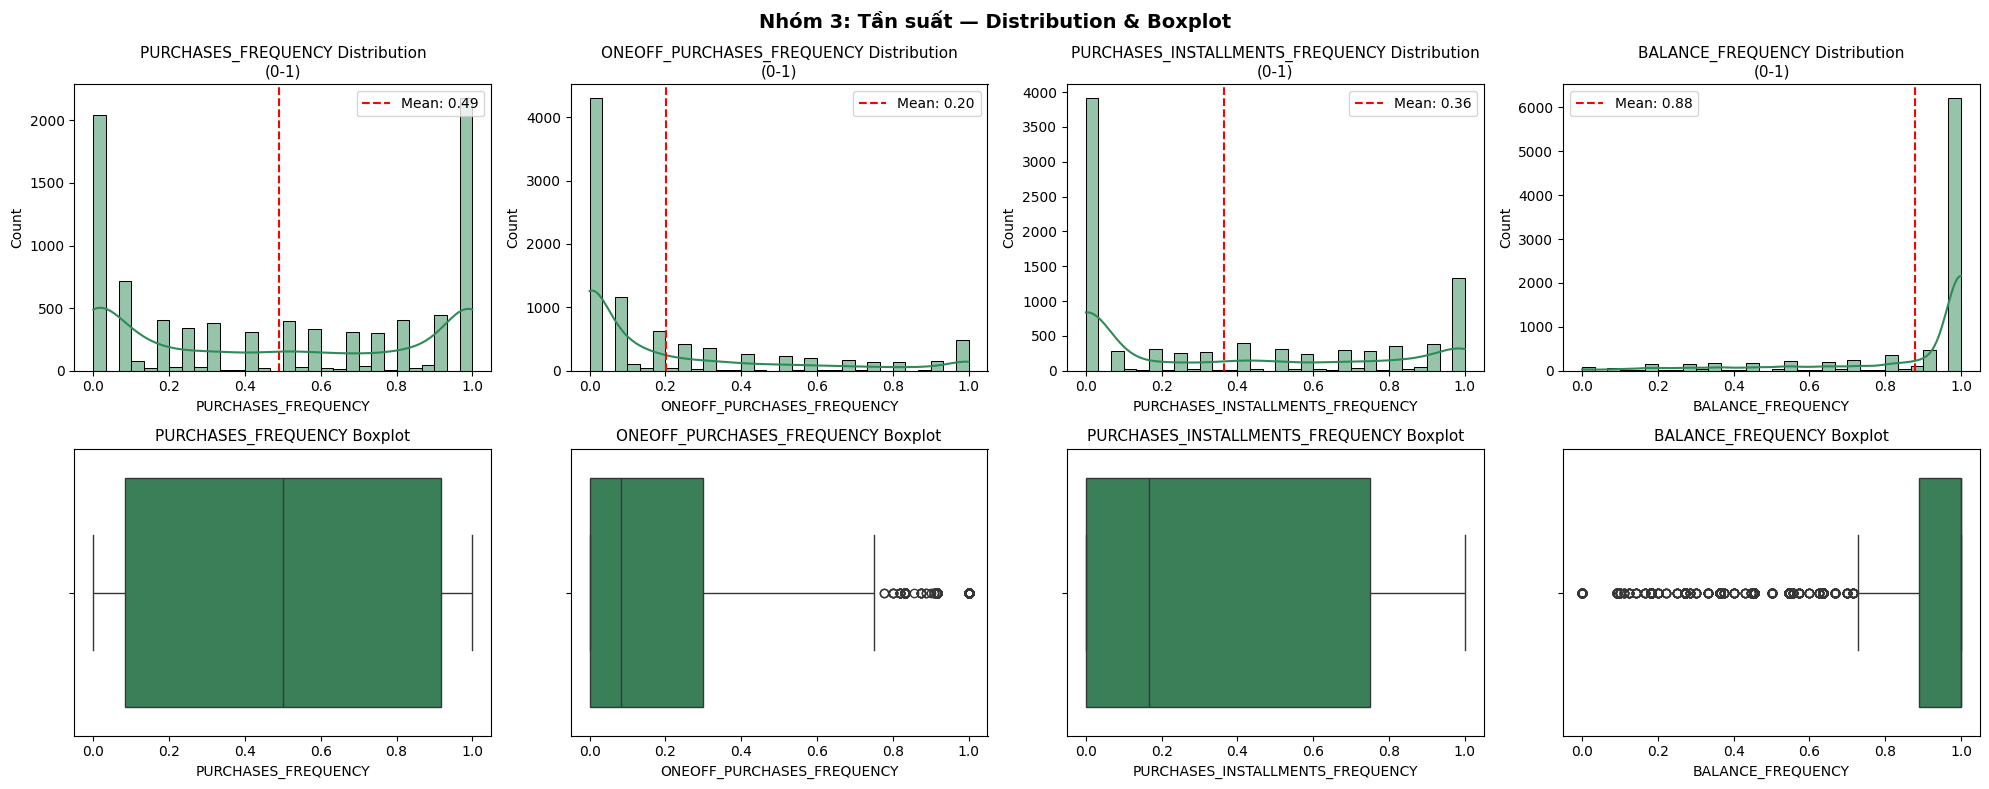

In [207]:
# =============================================
# Nhóm 3: Tần suất (FREQUENCY)
# =============================================
freq_cols = ['PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
             'PURCHASES_INSTALLMENTS_FREQUENCY', 'BALANCE_FREQUENCY']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(freq_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i], color='seagreen')
    axes[0, i].set_title(f'{col} Distribution\n(0-1)', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 3: Tần suất — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Nhóm 3 — Kết luận: Tần suất

| Feature | Mean | Kết luận |
|---------|------|---------|
| **PURCHASES_FREQUENCY** | 0.49 | Khách mua ít hơn nửa thời gian |
| **ONEOFF_PURCHASES_FREQUENCY** | 0.20 | Ít mua đứt, chuộng trả góp |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | 0.36 | Trả góp phổ biến hơn mua đứt |
| **BALANCE_FREQUENCY** | 0.88 | Hầu hết khách thanh toán thường xuyên |

> **Quan hệ:** INSTALL_FREQ (0.36) > ONEOFF_FREQ (0.20) → Khách **ưa trả góp hơn mua đứt**

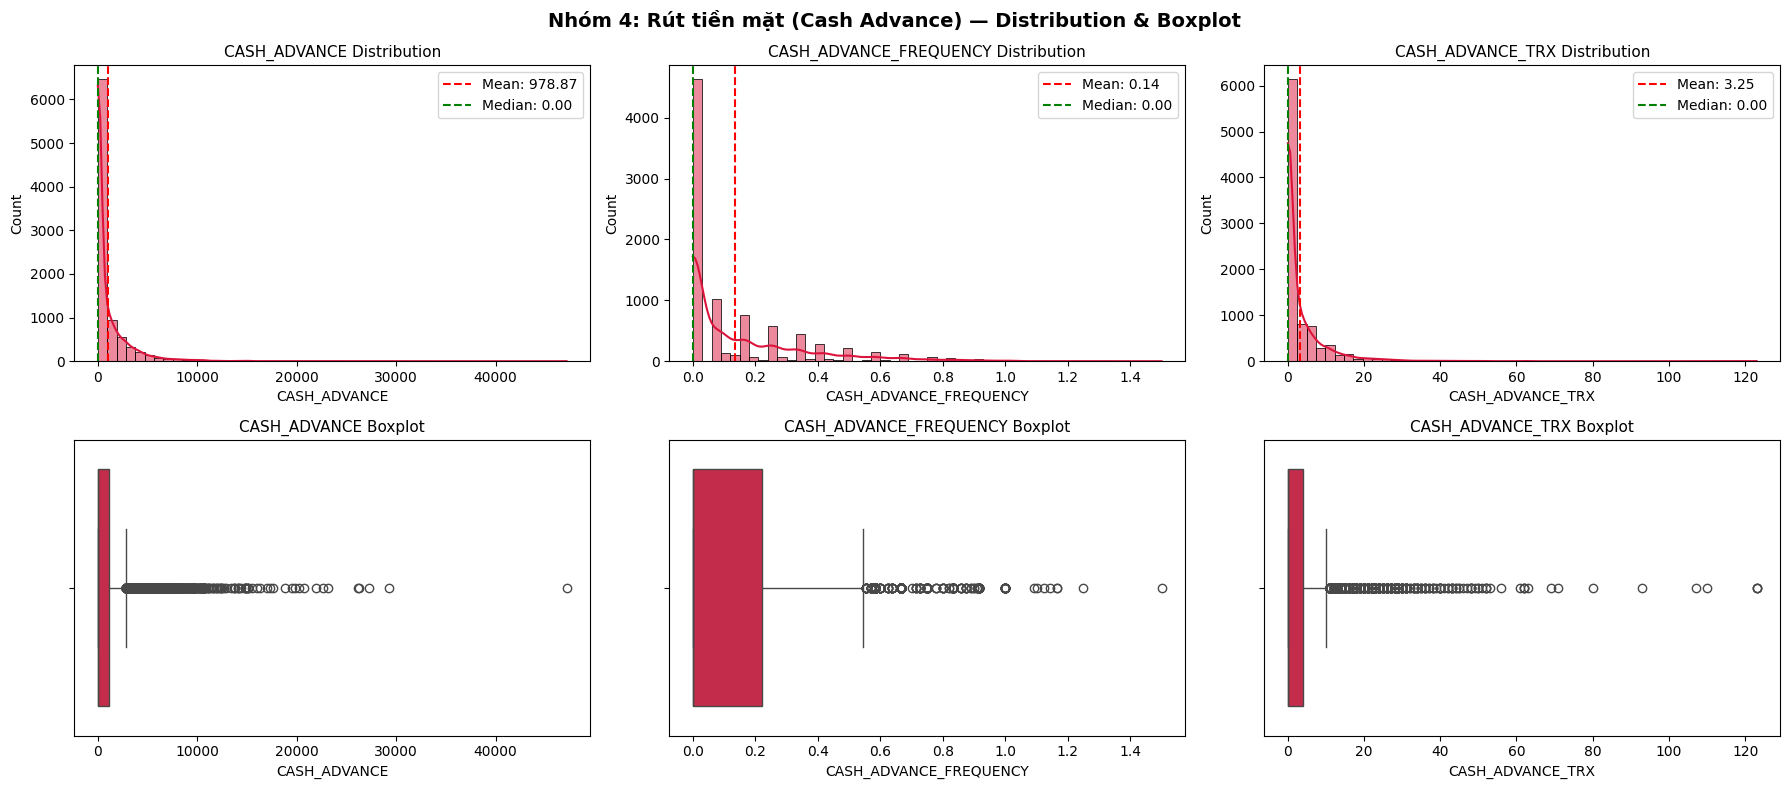

In [208]:
# =============================================
# Nhóm 4: Rút tiền mặt (CASH ADVANCE)
# =============================================
cash_cols = ['CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(cash_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='crimson')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='crimson')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 4: Rút tiền mặt (Cash Advance) — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Nhóm 4 — Kết luận: Rút tiền mặt (Cash Advance)

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **CASH_ADVANCE** | $979 | **$0** | >50% khách KHÔNG rút tiền mặt |
| **CASH_ADVANCE_FREQUENCY** | 0.14 | 0 | Hiếm khi rút tiền khi có giao dịch |
| **CASH_ADVANCE_TRX** | 3.2 | 0 | 50% khách có 0 giao dịch rút tiền |

> **Chú ý:** Nhóm rút tiền mặt là thiểu số nhưng **rất nặng** (max = $47,137) → Đây là nhóm **rủi ro tài chính**

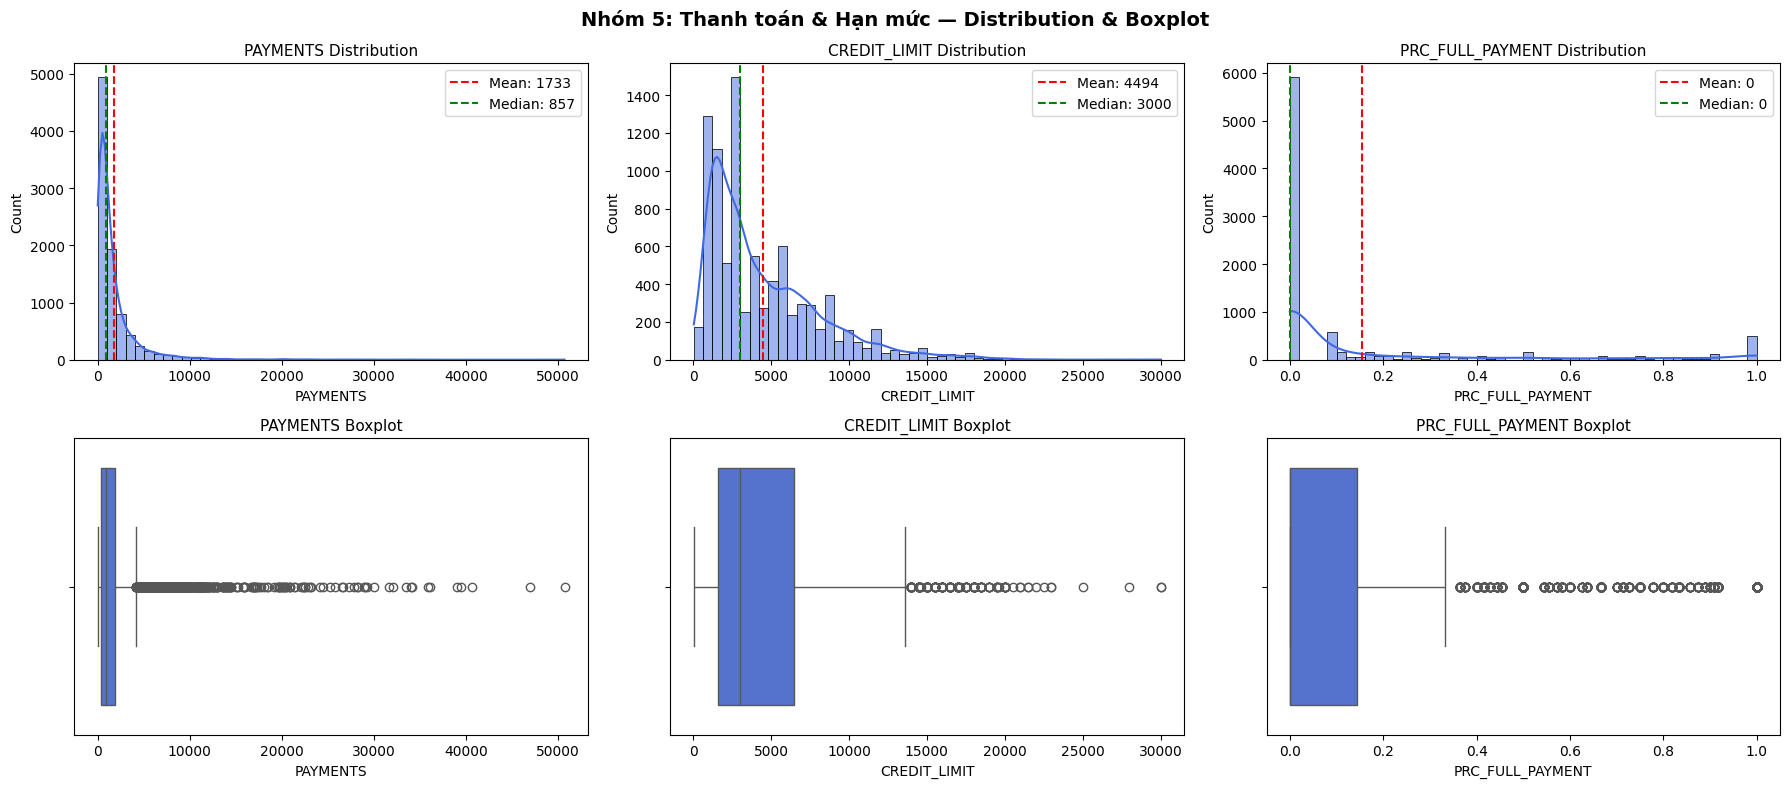

→ PAYMENTS: Mean > BALANCE Mean → Khách trả nhiều hơn nợ
→ CREDIT_LIMIT: Hầu hết khách có hạn mức < $5,000 (median = $3,000)
→ PRC_FULL_PAYMENT: Median=0 → >50% khách KHÔNG trả đủ nợ


In [209]:
# =============================================
# Nhóm 5: Thanh toán & Hạn mức (PAYMENTS)
# =============================================
pay_cols = ['PAYMENTS', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(pay_cols):
    # Hàng 1: Histogram + KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0, i], color='royalblue')
    axes[0, i].set_title(f'{col} Distribution', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[0, i].legend()

    # Hàng 2: Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color='royalblue')
    axes[1, i].set_title(f'{col} Boxplot', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Nhóm 5: Thanh toán & Hạn mức — Distribution & Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ PAYMENTS: Mean > BALANCE Mean → Khách trả nhiều hơn nợ")
print("→ CREDIT_LIMIT: Hầu hết khách có hạn mức < $5,000 (median = $3,000)")
print("→ PRC_FULL_PAYMENT: Median=0 → >50% khách KHÔNG trả đủ nợ")

### Nhóm 5 — Kết luận: Thanh toán & Hạn mức

| Feature | Mean | Median | Kết luận |
|---------|------|--------|---------|
| **PAYMENTS** | $1,733 | $857 | Mean > BALANCE → Khách trả nhiều hơn nợ |
| **CREDIT_LIMIT** | $4,494 | $3,000 | Hầu hết khách có hạn mức thấp (<$5,000) |
| **PRC_FULL_PAYMENT** | 15.4% | **0** | >50% khách KHÔNG trả đủ nợ |

> **Quan hệ quan trọng:**
> - `PAYMENTS_mean ($1,733) > BALANCE_mean ($1,564)` → Khách nhìn chung có trách nhiệm tài chính
> - `PRC_FULL_PAYMENT median = 0` → **Rủi ro** — hơn nửa khách không trả hết dư nợ

## Xử lý Outliers bằng Log Transform


In [237]:
# =============================================
# ÁP DỤNG LOG TRANSFORM
# =============================================
from scipy.stats import skew

# Lấy numerical columns (trừ Cluster nếu có)
num_cols = [col for col in df.columns if col != 'Cluster']

# Columns KHÔNG cần log transform (đã bounded 0-1)
freq_cols = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
             'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
             'PRC_FULL_PAYMENT', 'TENURE']

# Columns CẦN log transform (amount/ count — lệch phải)
amount_cols = [col for col in num_cols if col not in freq_cols]

# Lưu df gốc trước khi transform
df_original = df.copy()

# Áp dụng log1p cho amount columns
df_log = df.copy()
for col in amount_cols:
    df_log[col] = np.log1p(df_log[col])

# So sánh skewness trước vs sau
print("=" * 60)
print("SKEWNESS TRƯỚC vs SAU LOG TRANSFORM")
print("=" * 60)
print(f"\n{'Feature':<30} {'Before':>10} {'After':>10} {'Giảm':>8}")
print("-" * 60)

for col in num_cols:
    before = abs(skew(df[col].dropna()))
    after = abs(skew(df_log[col].dropna()))
    reduced = (before - after) / before * 100
    print(f"{col:<30} {before:>10.3f} {after:>10.3f} {reduced:>7.1f}%")

print("-" * 60)


SKEWNESS TRƯỚC vs SAU LOG TRANSFORM

Feature                            Before      After     Giảm
------------------------------------------------------------
BALANCE                             2.393      0.861    64.0%
BALANCE_FREQUENCY                   2.023      2.023     0.0%
PURCHASES                           8.143      0.764    90.6%
ONEOFF_PURCHASES                   10.043      0.186    98.1%
INSTALLMENTS_PURCHASES              7.298      0.025    99.7%
CASH_ADVANCE                        5.166      0.263    94.9%
PURCHASES_FREQUENCY                 0.060      0.060     0.0%
ONEOFF_PURCHASES_FREQUENCY          1.535      1.535     0.0%
PURCHASES_INSTALLMENTS_FREQUENCY      0.509      0.509     0.0%
CASH_ADVANCE_FREQUENCY              1.828      1.828     0.0%
CASH_ADVANCE_TRX                    5.720      0.940    83.6%
PURCHASES_TRX                       4.630      0.033    99.3%
CREDIT_LIMIT                        1.522      0.102    93.3%
PAYMENTS                        

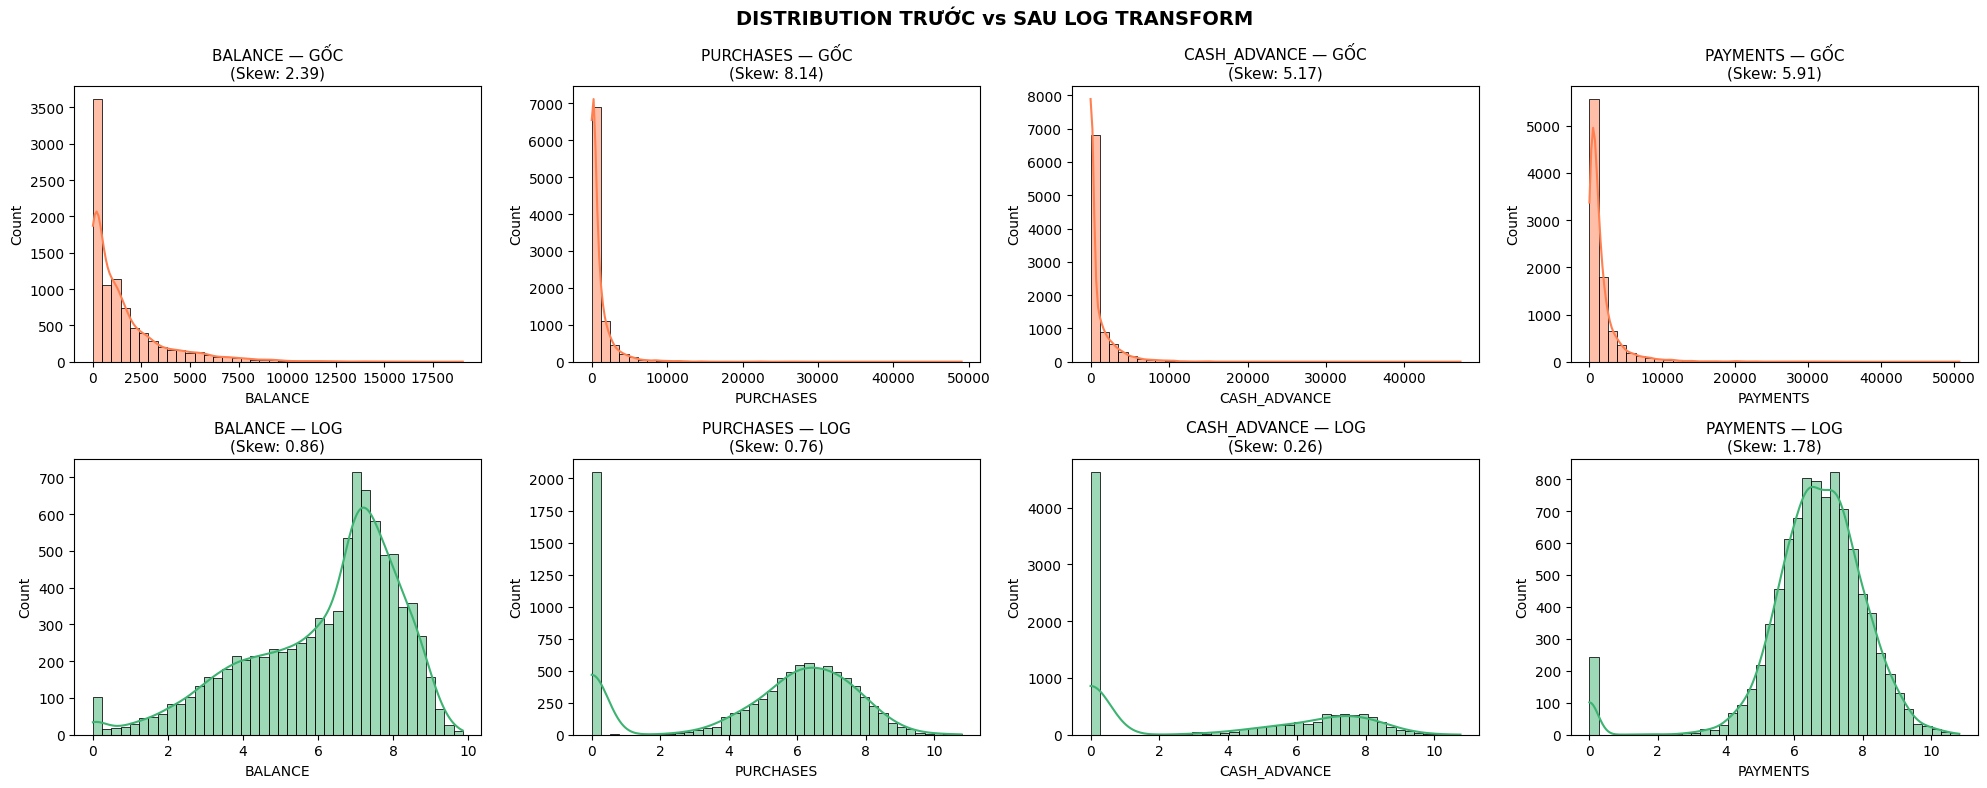

→ Phân phối sau log transform gần normal hơn → Tốt cho K-Means clustering


In [238]:
# =============================================
# TRƯỚC vs SAU: Distribution Comparison
# =============================================
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(key_features):
    # Hàng 1: Distribution GỐC
    sns.histplot(df_original[col].dropna(), bins=40, kde=True, ax=axes[0, i], color='coral')
    axes[0, i].set_title(f'{col} — GỐC\n(Skew: {abs(skew(df_original[col])):.2f})', fontsize=11)
    axes[0, i].set_xlabel(col)

    # Hàng 2: Distribution SAU LOG
    sns.histplot(df_log[col].dropna(), bins=40, kde=True, ax=axes[1, i], color='mediumseagreen')
    axes[1, i].set_title(f'{col} — LOG\n(Skew: {abs(skew(df_log[col])):.2f})', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('DISTRIBUTION TRƯỚC vs SAU LOG TRANSFORM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Phân phối sau log transform gần normal hơn → Tốt cho K-Means clustering")

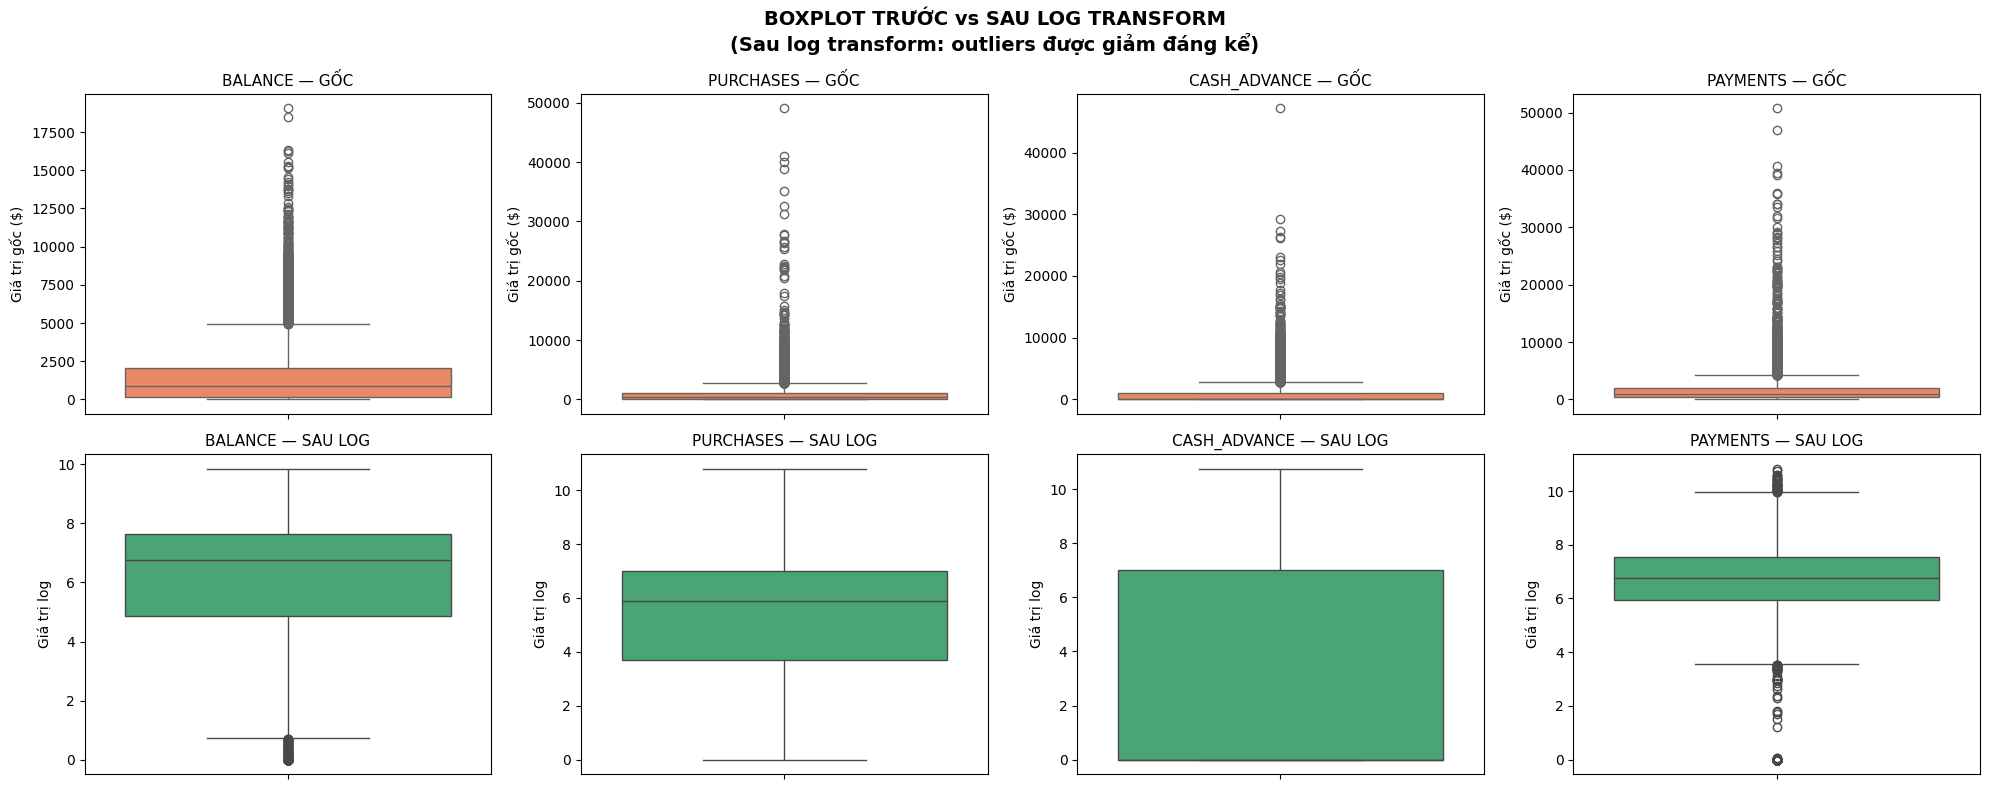

→ Hàng trên (GỐC): Outliers nặng, scale không đồng đều
→ Hàng dưới (LOG): Outliers giảm rõ rệt, scale đồng đều hơn
→ Log transform giúp giảm ảnh hưởng của outliers → K-Means hiệu quả hơn


In [240]:
# =============================================
# TRƯỚC vs SAU: BOXPLOT COMPARISON
# =============================================
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(key_features):
    # Hàng 1: Boxplot GỐC
    sns.boxplot(y=df_original[col], ax=axes[0, i], color='coral')
    axes[0, i].set_title(f'{col} — GỐC', fontsize=11)
    axes[0, i].set_ylabel('Giá trị gốc ($)')

    # Hàng 2: Boxplot SAU LOG
    sns.boxplot(y=df_log[col], ax=axes[1, i], color='mediumseagreen')
    axes[1, i].set_title(f'{col} — SAU LOG', fontsize=11)
    axes[1, i].set_ylabel('Giá trị log')

plt.suptitle('BOXPLOT TRƯỚC vs SAU LOG TRANSFORM\n(Sau log transform: outliers được giảm đáng kể)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Hàng trên (GỐC): Outliers nặng, scale không đồng đều")
print("→ Hàng dưới (LOG): Outliers giảm rõ rệt, scale đồng đều hơn")
print("→ Log transform giúp giảm ảnh hưởng của outliers → K-Means hiệu quả hơn")

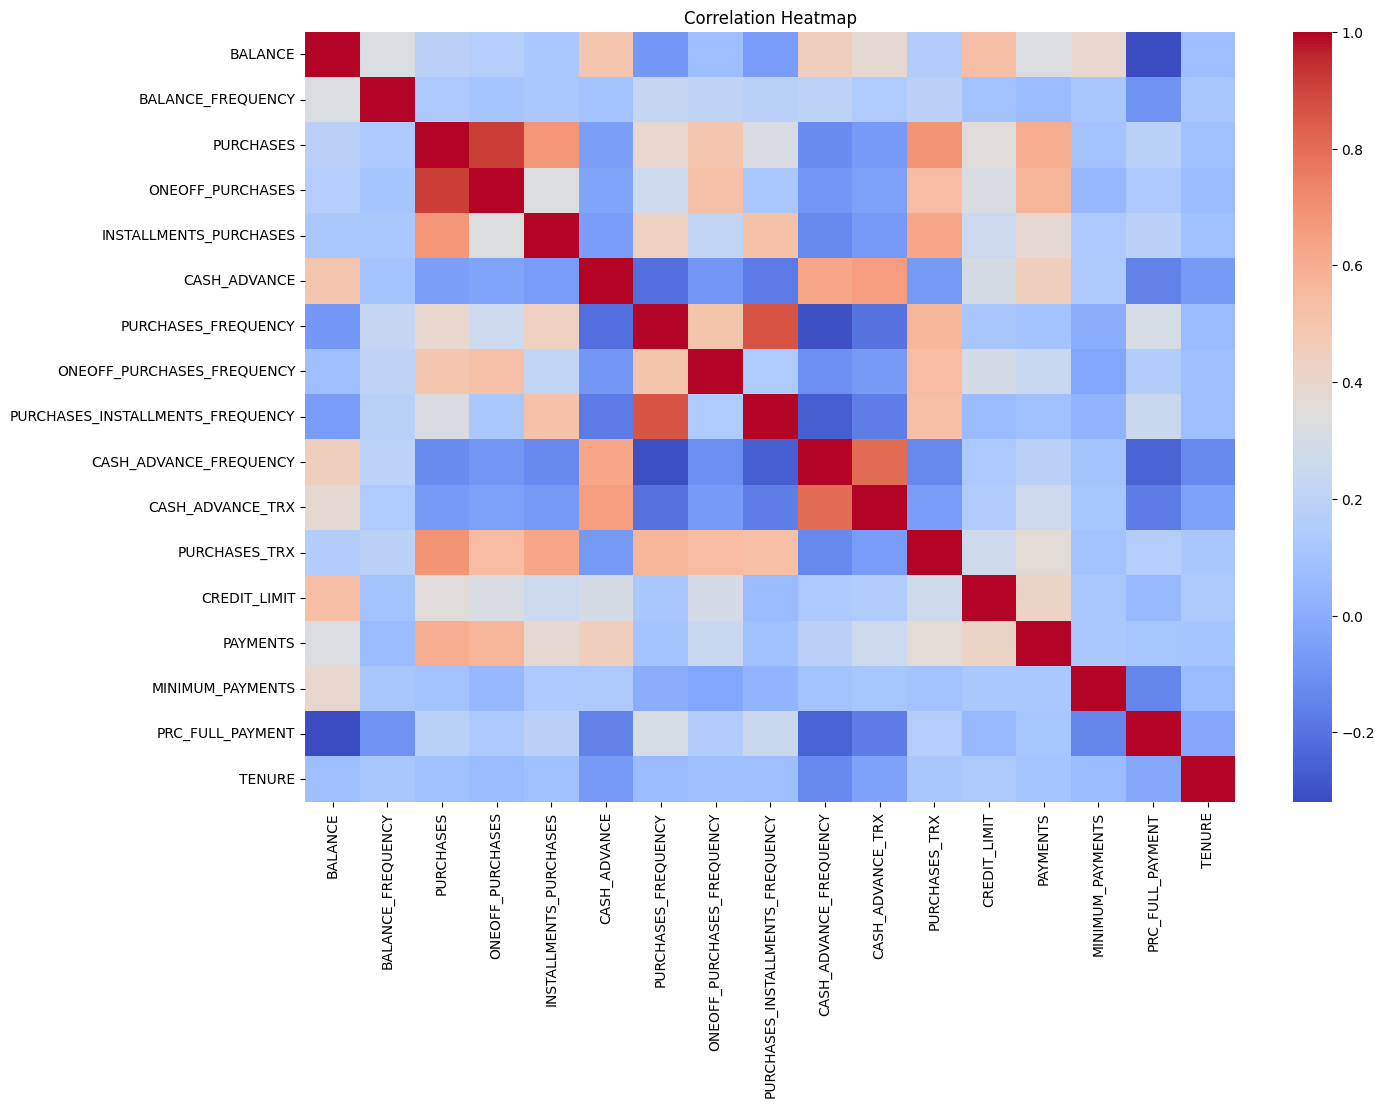

In [210]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

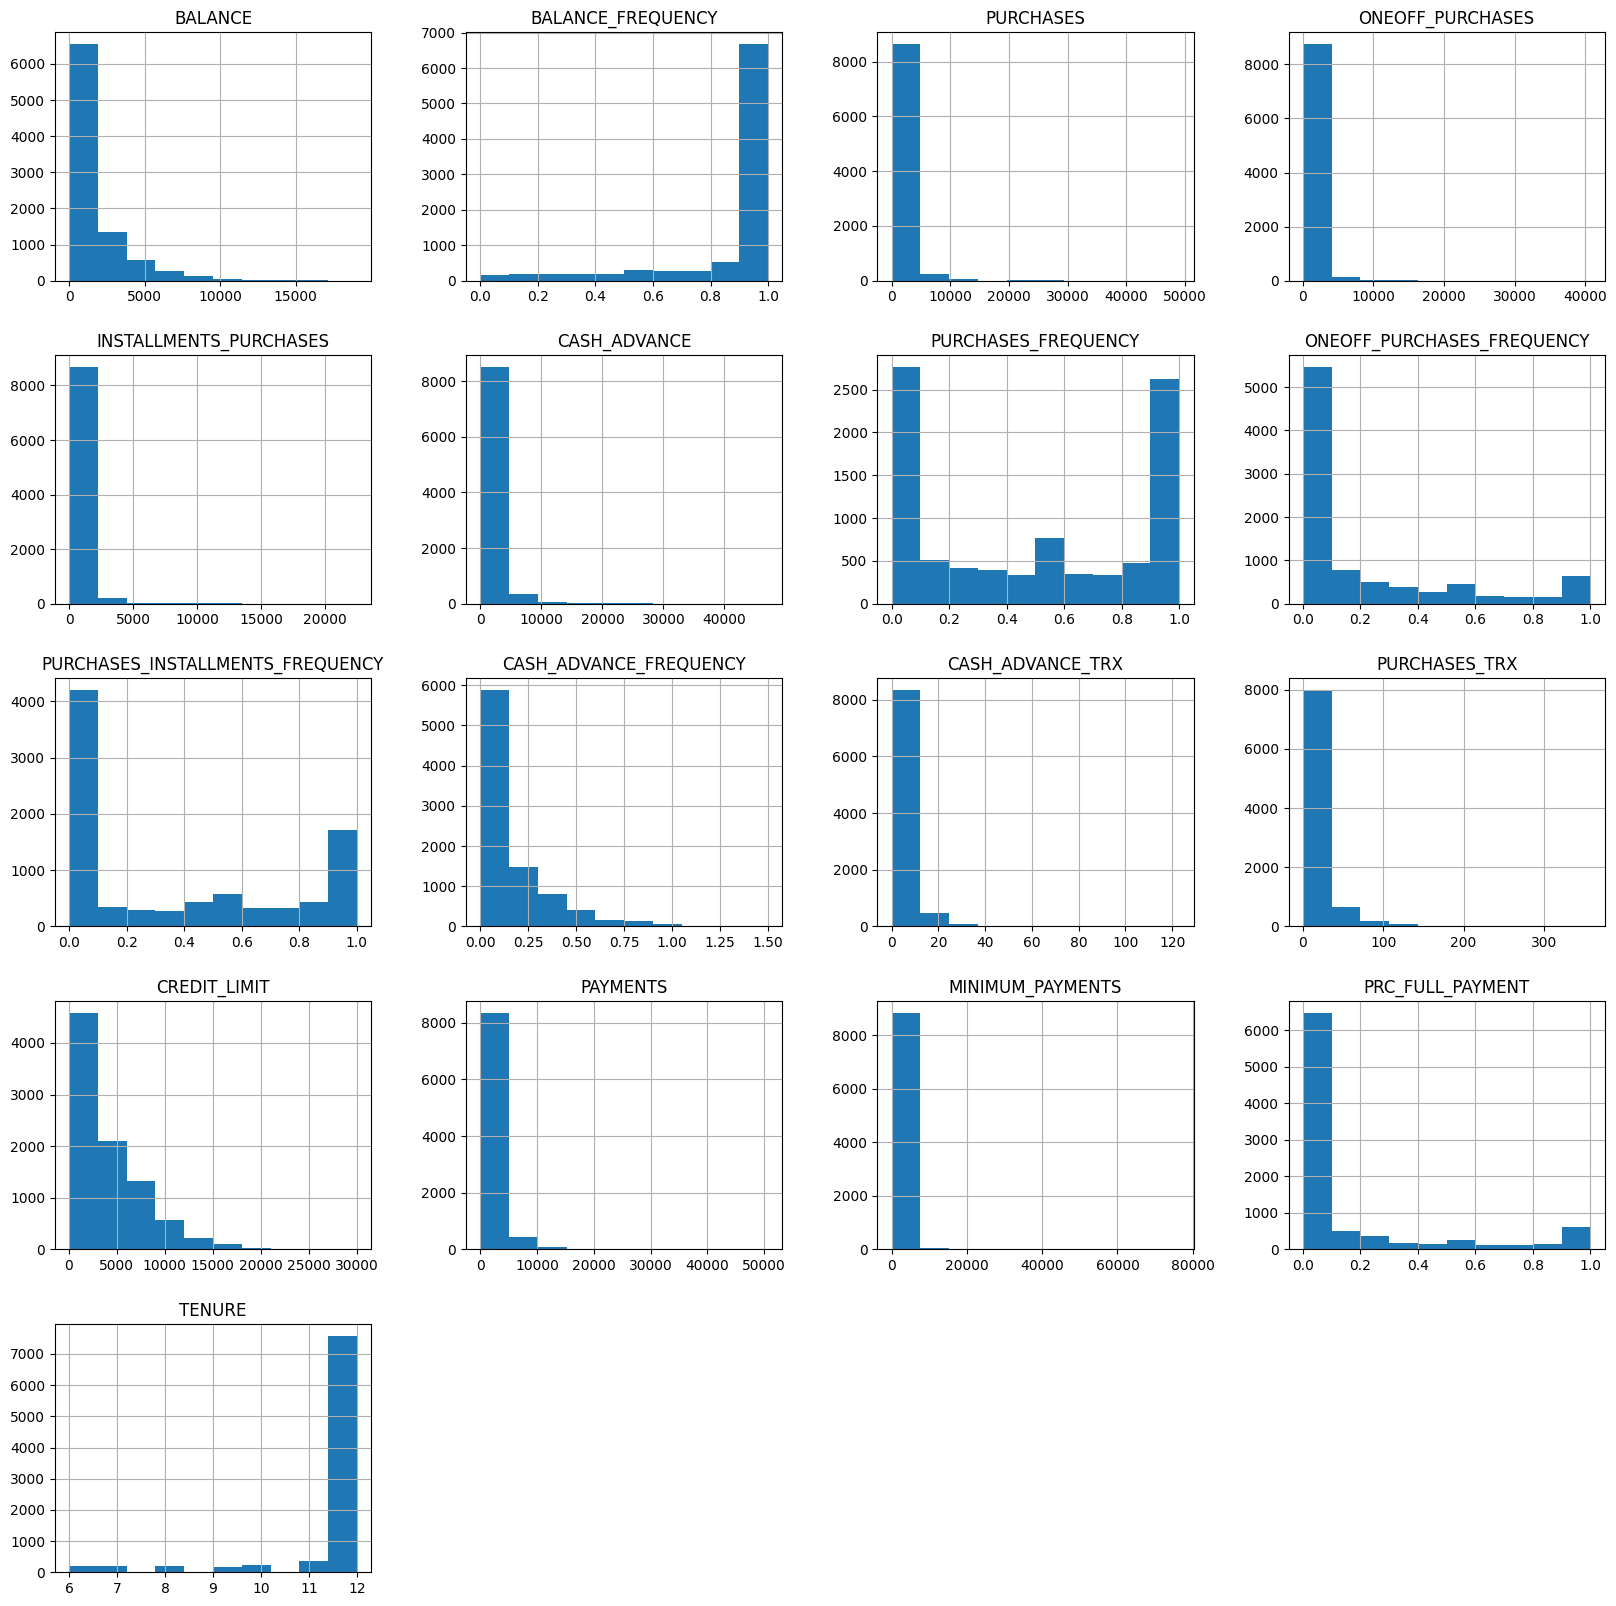

In [211]:
df.hist(figsize=(20,20))
plt.show()

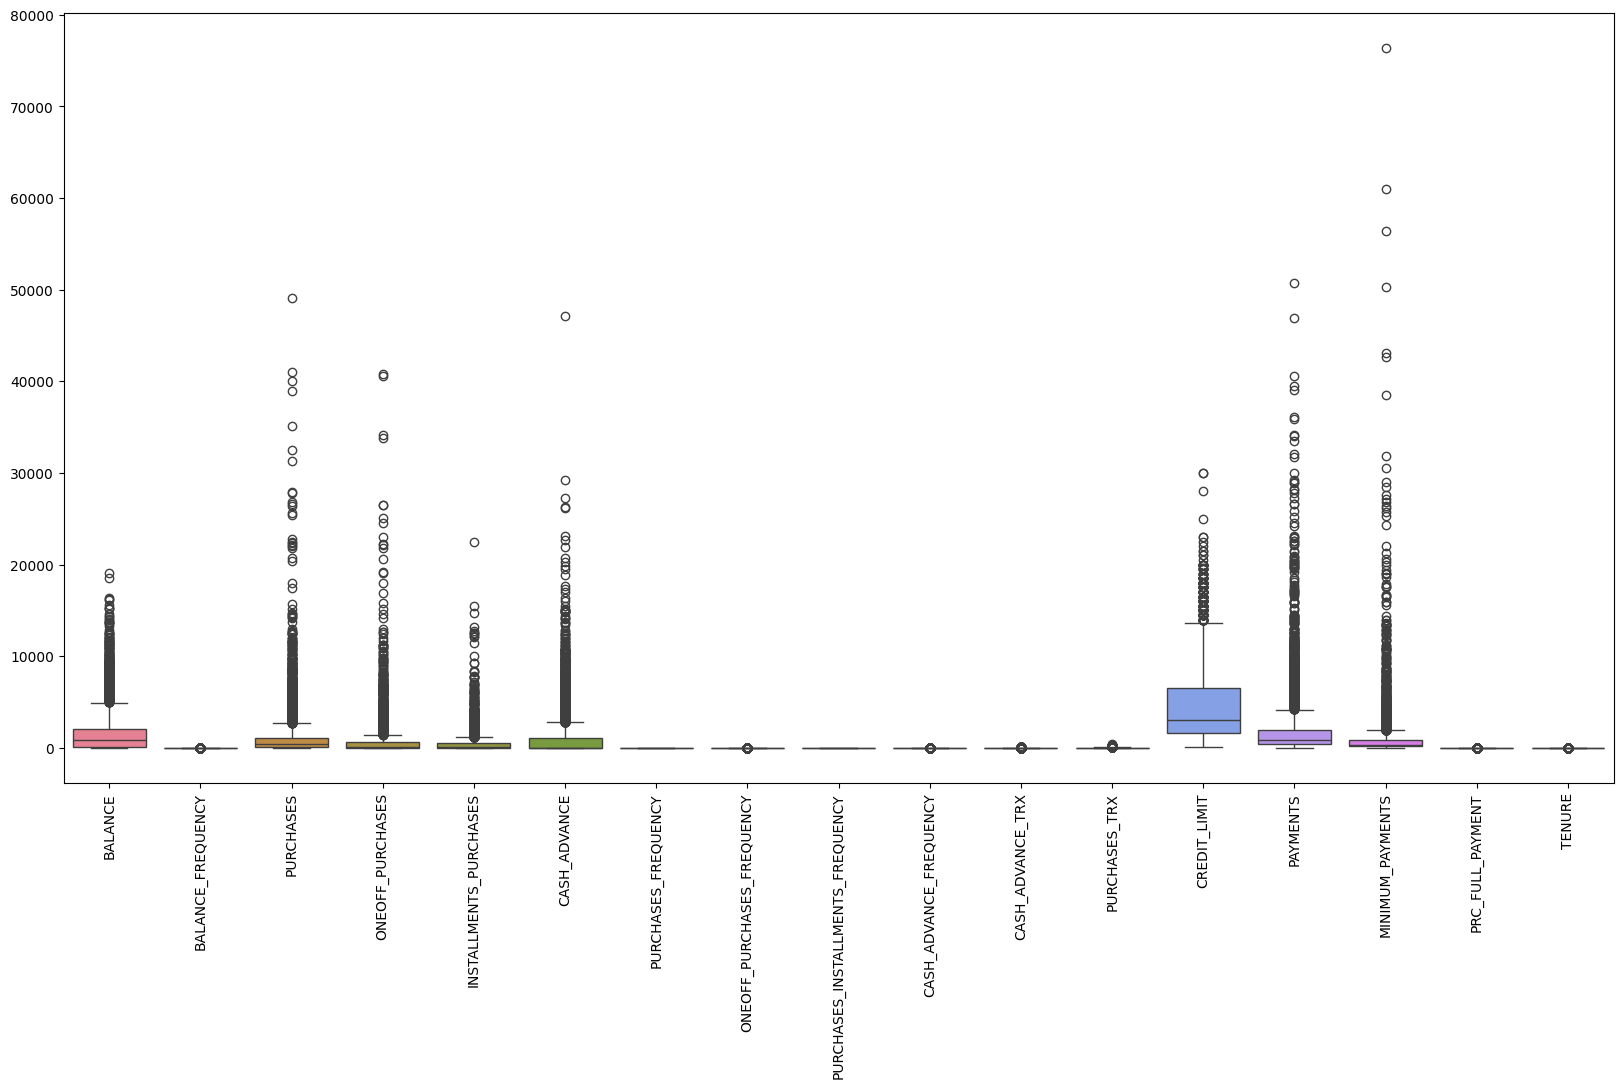

In [212]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

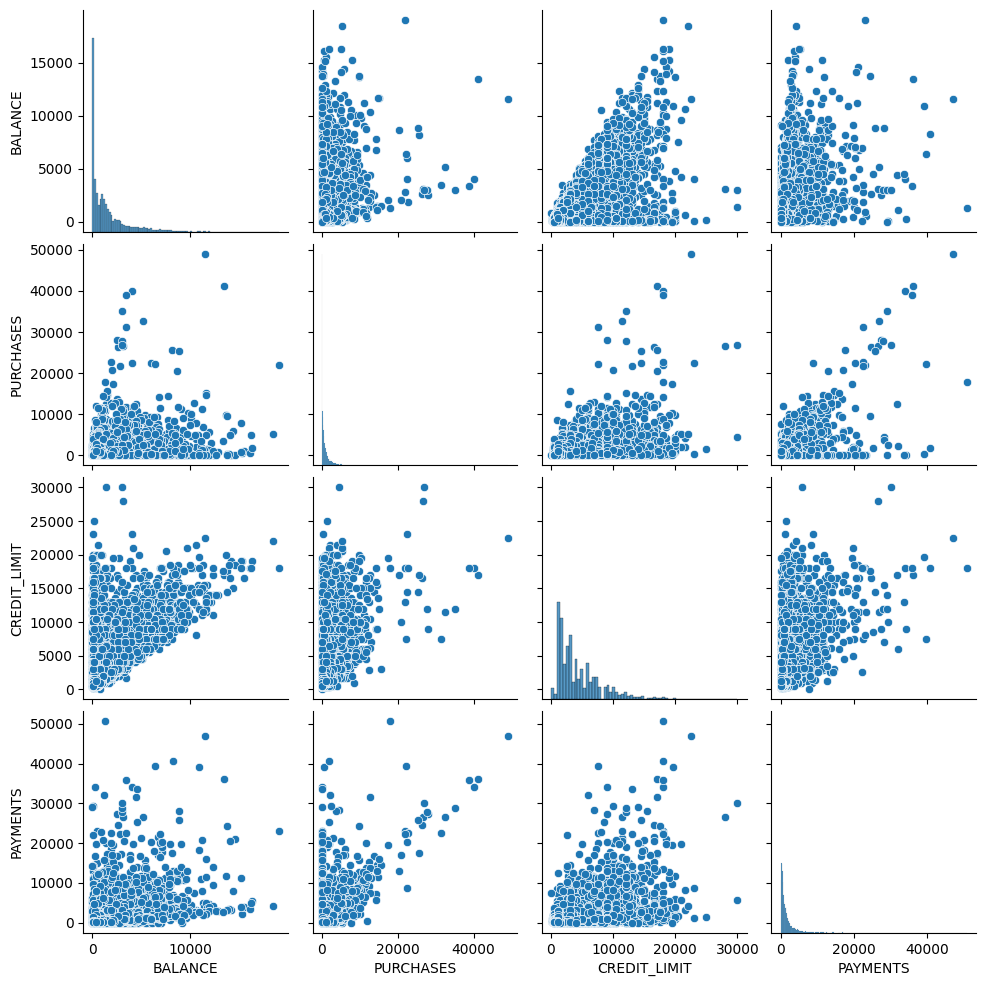

In [213]:
sample_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

sns.pairplot(df[sample_cols])
plt.show()

DATA TRANSFORMATION

In [214]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [215]:
scaled_data

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

K-MEANS CLUSTERING

In [216]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

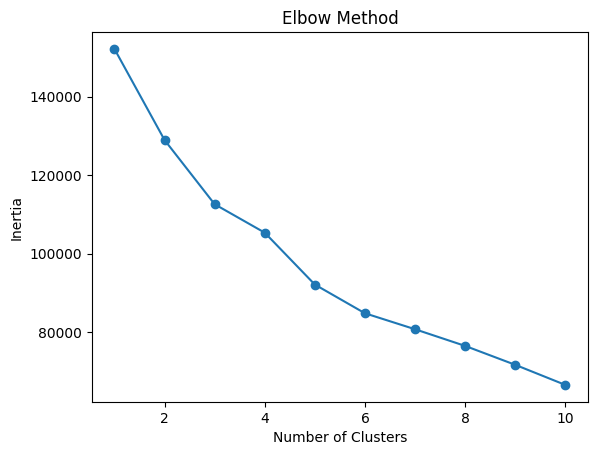

In [217]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [218]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

In [219]:
df["Cluster"] = clusters

PCA VISUALIZATION

In [220]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [221]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

In [222]:
pca_df["Cluster"] = clusters

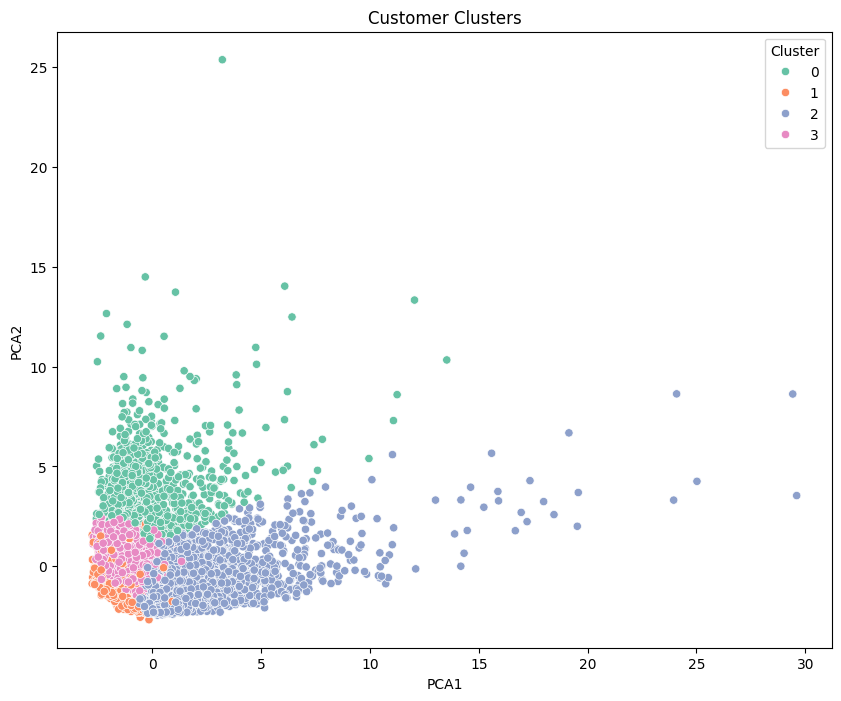

In [223]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("Customer Clusters")
plt.show()

KNN + DECISION TREE

In [224]:
selected_features = [
    'BALANCE',
    'PURCHASES',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

X = df[selected_features]

y = df["Cluster"]

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [226]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [227]:
y_pred_knn = knn.predict(X_test)

In [228]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_knn)

0.7156424581005587

In [229]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [230]:
y_pred_tree = tree.predict(X_test)

In [231]:
accuracy_score(y_test, y_pred_tree)

0.7229050279329609

EVALUATION

In [232]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_knn)

array([[102,   3,  26,  54],
       [  9, 180,  67,  28],
       [ 18,  47, 494,  69],
       [ 32,  57,  99, 505]])

In [233]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.63      0.55      0.59       185
           1       0.63      0.63      0.63       284
           2       0.72      0.79      0.75       628
           3       0.77      0.73      0.75       693

    accuracy                           0.72      1790
   macro avg       0.69      0.68      0.68      1790
weighted avg       0.72      0.72      0.71      1790



SAVE MODEL

In [234]:
import joblib

joblib.dump(kmeans, "../models/kmeans.pkl")

joblib.dump(knn, "../models/knn.pkl")

joblib.dump(tree, "../models/tree.pkl")

FileNotFoundError: [Errno 2] No such file or directory: '../models/kmeans.pkl'